In [150]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os

In [184]:
lengde = 20_000

def create_pop(lengde):
    population = {
        "sex":[random.choice(['K', 'M']) for _ in range(lengde)], 
        "alder":[random.randint(0, 94) for _ in range(lengde)],
        "barn": [0] * lengde
    
    }
    df = pd.DataFrame(population)
  
    return df

create_pop(100_000)

,sex,alder,barn
0,K,36,0
1,K,26,0
2,K,77,0
3,M,84,0
4,M,31,0
...,...,...,...
99995,M,38,0
99996,M,21,0
99997,M,77,0
99998,M,54,0


In [185]:
innvandring = pd.read_csv("nettoinvandring.csv")
innvandring

,år,nettoinnvandring
0,2007,39652
1,2008,43346
2,2009,38637
3,2010,42346
4,2011,47032
5,2012,47343
6,2013,40073
7,2014,38170
8,2015,29773
9,2016,26093


In [186]:
initial_value = innvandring.nettoinnvandring.mean()

percentage_change = -0.05

# Define the number of iterations
iterations = 102

# Create a list to store the values
values_list = [initial_value]

# Iteratively multiply the value by the percentage change
for i in range(1, iterations):
    new_value = values_list[-1] * (1 + percentage_change)
    values_list.append(new_value)

print(values_list)

[33878.333333333336, 32184.416666666668, 30575.19583333333, 29046.436041666664, 27594.11423958333, 26214.408527604162, 24903.688101223954, 23658.503696162756, 22475.578511354615, 21351.799585786885, 20284.209606497538, 19269.99912617266, 18306.499169864026, 17391.174211370824, 16521.615500802283, 15695.534725762169, 14910.75798947406, 14165.220090000355, 13456.959085500337, 12784.11113122532, 12144.905574664053, 11537.66029593085, 10960.777281134306, 10412.73841707759, 9892.10149622371, 9397.496421412523, 8927.621600341896, 8481.2405203248, 8057.1784943085595, 7654.319569593131, 7271.603591113474, 6908.0234115578, 6562.622240979909, 6234.491128930914, 5922.766572484368, 5626.628243860149, 5345.296831667141, 5078.031990083784, 4824.130390579595, 4582.923871050615, 4353.777677498084, 4136.088793623179, 3929.28435394202, 3732.820136244919, 3546.179129432673, 3368.8701729610393, 3200.426664312987, 3040.4053310973377, 2888.385064542471, 2743.9658113153473, 2606.76752074958, 2476.42914471210

In [187]:
age_groups = {"child":0.001,
             "adult" : 0.003,
             "senior": 0.02}

current_average = sum(age_groups.values()) / len(age_groups)
current_average

0.008

In [286]:
import pandas as pd
import random
from tqdm import tqdm

dødsrate = 0.008

def get_age_group(age):
    if age < 25:
        return 'child'
    elif age < 65:
        return 'adult'
    else:
        return 'senior'
    
def populasjonsutvikling(df, TFR, år, fruktbare_år, eldste_fødsel, innvandring=True,  innvandringsgrad = 0.95):
    print(f"Regner populasjon med\nTFR={TFR}\nFruktbare år: {fruktbare_år}\nEldste fødsel: {eldste_fødsel}\n{år} år")
    
    liste_med_antall_personer = []
    sannsynlighet_for_barn = TFR / fruktbare_år
    

    for year in tqdm(range(år)):
        # Legger til 1 i alder på hele populasjonen
        df['alder'] += 1
       # yearly_pop.append(len(df))
        
        # Definerer fruktbare damer
        fruktbare_damer = df.loc[(df.alder > eldste_fødsel-fruktbare_år) & (df.alder < eldste_fødsel) & (df.barn < 4) & (df.sex == "K")]
        num_fruktbare_damer = len(fruktbare_damer)
        # Henter antall nye kids
        num_nye_kids = int(num_fruktbare_damer * sannsynlighet_for_barn)

        nye_kids = (
            pd.DataFrame({
                "sex": [random.choice(['K', 'M']) for _ in range(num_nye_kids)], 
                "alder": [0] * num_nye_kids,
                "barn": [0] * num_nye_kids}))
        
        # øker antall barn for damene som får barn.
        df.loc[fruktbare_damer.sample(num_nye_kids, random_state=42).index, "barn"] += 1

        # Assign weights once
        df['age_group'] = df['alder'].apply(get_age_group)
        df['weights'] = df['age_group'].map(age_groups)
        
        # Regner ut antall døe personer
        antall_døde = int(len(df) * dødsrate)
        døde = df.sample(n=antall_døde, weights='weights', random_state=42).index
        df = df.drop(døde)
        
        # legger til innvandring i populasjonen
        if innvandring == True:
            if year in [0,1]:
                innvandrere = 40_000
            else:
                innvandrere = int(40_000 * innvandringsgrad**year)
        else:
            innvandrere = 0

        innvandrere_df = (
            pd.DataFrame({
                "sex": [random.choice(['K', 'M']) for _ in range(innvandrere)], 
                "alder": [0] * innvandrere,
                "barn": [0] * innvandrere}))

        df = pd.concat([df, nye_kids, innvandrere_df]).reset_index(drop=True)
        df.drop(columns=['weights'], inplace=True)

        liste_med_antall_personer.append(len(df))
        
        
    return liste_med_antall_personer, df

In [287]:
befolkning_for_2023 = pd.read_csv("befolkning.csv")#.loc[lambda x: x.år <= 2022]

In [288]:
start_pop = befolkning_for_2023.loc[lambda x: x.år == 2024, "pop"].values[0]
start_pop

5550203

<Axes: xlabel='år'>

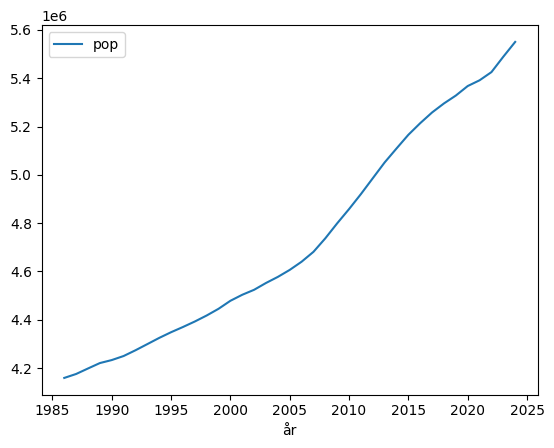

In [289]:
befolkning_for_2023.plot(x="år")

<Axes: xlabel='år'>

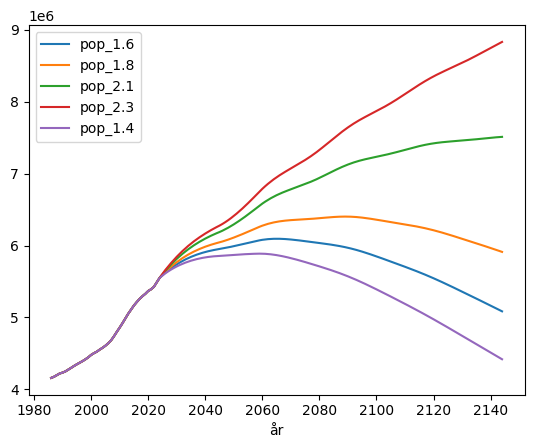

In [290]:
fremskrivning = pd.read_csv('TFR_14_16_18_21_23_aar_1986_2144.csv')
fremskrivning.plot(x = "år")

In [298]:
# Demonstrasjon av Norge
befolkningsutvikling = pd.DataFrame()
år_start = 1986
år = 150
år_slutt = (år_start) + (2025 - år_start) + år
fruktbare_år = 15
eldste_fødsel = 35
befolkningsutvikling["år"] = range(år_start, år_slutt)
# befolkningsutvikling


In [ ]:
tfrs = [1.4]

for tfr in tfrs:
    df_for_run = create_pop(start_pop)
    utvikling, df = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel)
    utvikling = pd.concat([befolkning_for_2023["pop"], pd.Series(utvikling)]).reset_index(drop=True)
    befolkningsutvikling[f"pop_{tfr}"] = utvikling


Regner populasjon med
TFR=1.4
Fruktbare år: 15
Eldste fødsel: 35
150 år


 82% 123/150 [05:05<00:54,  2.02s/it]

<Axes: xlabel='år'>

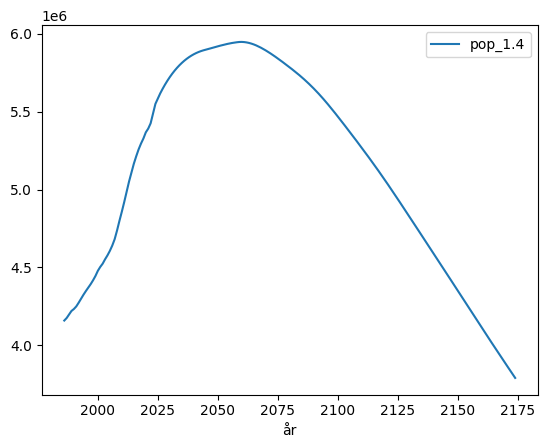

In [304]:
(
    befolkningsutvikling
   # .loc[lambda x: x.år < 2100]
    
    .plot(x="år", y = befolkningsutvikling.columns[1]))

In [305]:
df

,sex,alder,barn,age_group
0,M,179,0,senior
1,K,190,0,senior
2,K,244,0,senior
3,M,191,0,senior
4,K,195,0,senior
...,...,...,...,...
3790837,M,0,0,NaN
3790838,K,0,0,NaN
3790839,K,0,0,NaN
3790840,M,0,0,NaN


In [306]:
aldersfordeling = df.alder.value_counts().reset_index().sort_values("alder").rename(columns={"count":"antall"})
aldersfordeling

,alder,antall
207,0,7696
206,1,7817
204,2,7952
201,3,8079
200,4,8212
...,...,...
214,240,7131
223,241,7018
220,242,7035
221,243,7033


<BarContainer object of 245 artists>

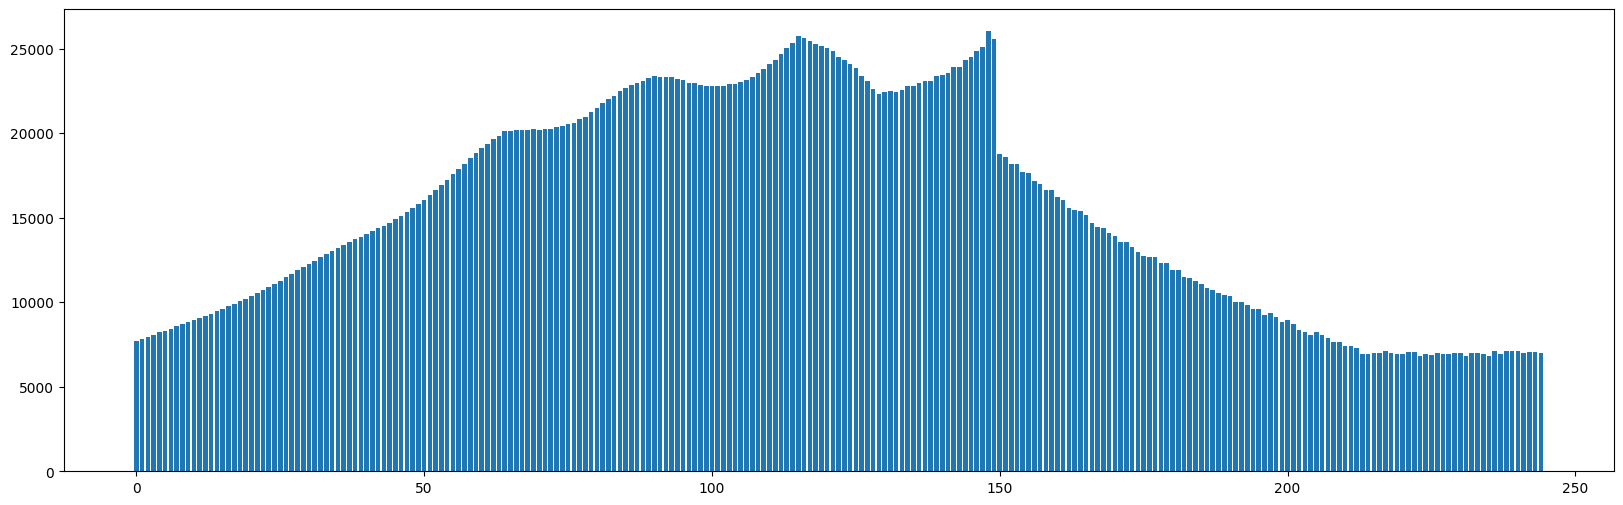

In [307]:
plt.figure(figsize=(20, 6))
plt.bar(list(aldersfordeling.alder), aldersfordeling.antall )

In [208]:
start_pop = list(befolkningsutvikling["pop_1.4"])[-1]
start_pop

3141982

In [ ]:
start_pop

In [ ]:
df

In [ ]:
år_start = 2150
år = 120
år_slutt = (år_start) + (2025 - år_start) + år
fruktbare_år = 15
eldste_fødsel = 35

In [310]:
ny_befolkning_etter = pd.DataFrame()

tfrs = (
    [
        1.4,
        1.7, 
        2.1, 
        2.8,
    ]
)

for tfr in tfrs:
    df_for_run = df
    utvikling, df_out = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel, innvandring = False)
    utvikling = pd.Series(utvikling).reset_index(drop=True)
    ny_befolkning_etter[f"{tfr}"] = utvikling

Regner populasjon med
TFR=1.4
Fruktbare år: 15
Eldste fødsel: 35
150 år


100% 150/150 [02:47<00:00,  1.12s/it]


Regner populasjon med
TFR=1.7
Fruktbare år: 15
Eldste fødsel: 35
150 år


100% 150/150 [02:54<00:00,  1.16s/it]


Regner populasjon med
TFR=2.1
Fruktbare år: 15
Eldste fødsel: 35
150 år


100% 150/150 [03:02<00:00,  1.22s/it]


Regner populasjon med
TFR=2.8
Fruktbare år: 15
Eldste fødsel: 35
150 år


100% 150/150 [03:26<00:00,  1.38s/it]


<Axes: >

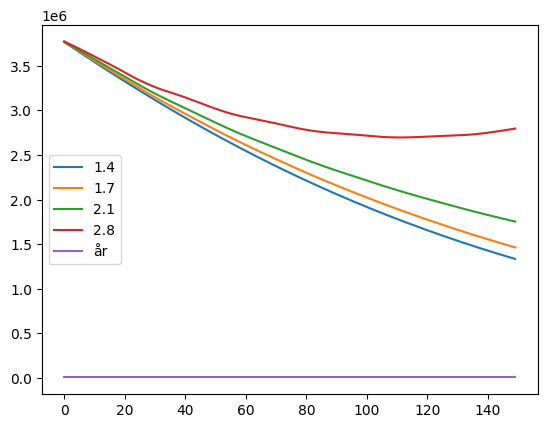

In [316]:
ny_befolkning_etter.plot()

In [317]:
ny_befolkning_etter["år"] = range(befolkningsutvikling.år.max()+1, befolkningsutvikling.år.max() + len(ny_befolkning_etter)+1)
ny_befolkning_etter

,1.4,1.7,2.1,2.8,år
0,3768065,3769547,3771468,3774877,2175
1,3745351,3748246,3752055,3758768,2176
2,3722677,3726966,3732606,3742481,2177
3,3700066,3705710,3713101,3726035,2178
4,3677518,3684462,3693562,3709422,2179
...,...,...,...,...,...
145,1373704,1502150,1784953,2775316,2320
146,1363423,1492153,1776938,2780680,2321
147,1353212,1482215,1768981,2786096,2322
148,1343073,1472336,1761068,2791519,2323


In [322]:
ny_befolkning_etter.to_csv("ny_befolkning_etter_1_4.csv", index=False)

In [323]:
befolkningsutvikling.loc[lambda x: x.år == 2025]["pop_1.4"]

39    5584014
Name: pop_1.4, dtype: int64

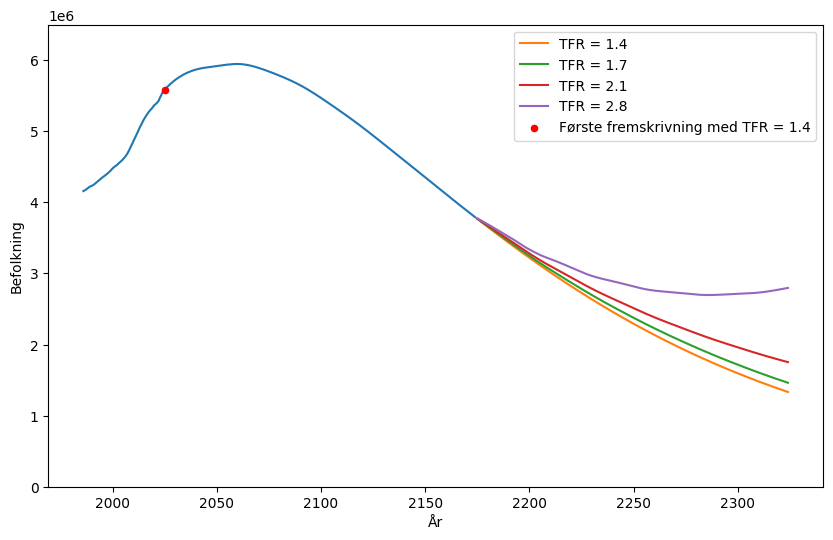

In [324]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(befolkningsutvikling.år, befolkningsutvikling["pop_1.4"]) 

for col in ny_befolkning_etter.columns:
    if col != "år":
        plt.plot(ny_befolkning_etter.år, ny_befolkning_etter[col], label = f"TFR = {col}")


plt.xlabel('År')
plt.ylabel('Befolkning')
plt.scatter(x=2025, y= befolkningsutvikling.loc[lambda x: x.år == 2025]["pop_1.4"], color="red", s = 20, zorder = 5, label = "Første fremskrivning med TFR = 1.4")
plt.legend()
plt.ylim(0, 6.5e6)
#plt.grid(True)
plt.show()